### Рукописные цифры MNIST

___

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import utils
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
%matplotlib inline

In [3]:
from tensorflow.keras.datasets import mnist

In [47]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [48]:
class_names = ['Ноль', "Единица", "Двойка", "Тройка",
              "Четвёрка", "Пятёрка", "Шестёрка", "Семёрка", "Восьмёрка",
              "Девятка"]

___

# Предобработка данных

In [49]:
x_train.shape, x_test.shape

((60000, 28, 28), (10000, 28, 28))

In [50]:
y_train.shape, y_test.shape

((60000,), (10000,))

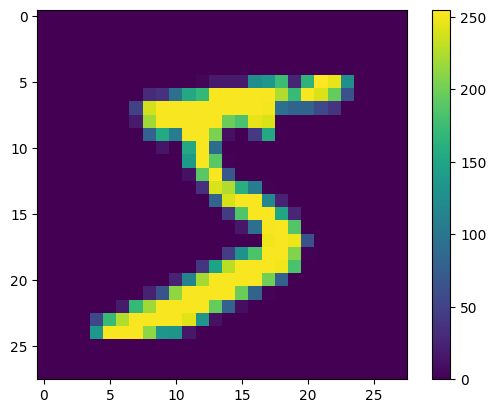

In [51]:
plt.figure()
plt.imshow(x_train[0])
plt.colorbar()
plt.grid(False)

___

### Нормализация данных

In [52]:
# Масштабируем значения пикселей в диапазон [0.0, 1.0] (после 255)
x_train = x_train / 255
x_test = x_test / 255

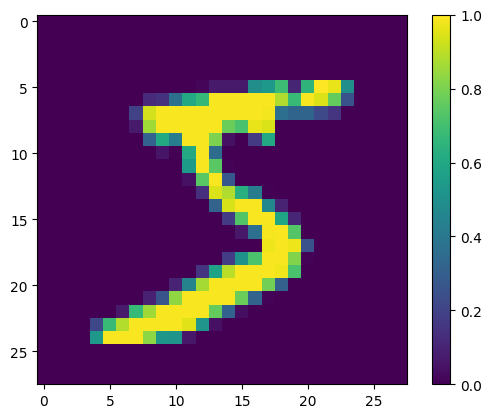

In [53]:
plt.figure()
plt.imshow(x_train[0])
plt.colorbar()
plt.grid(False)

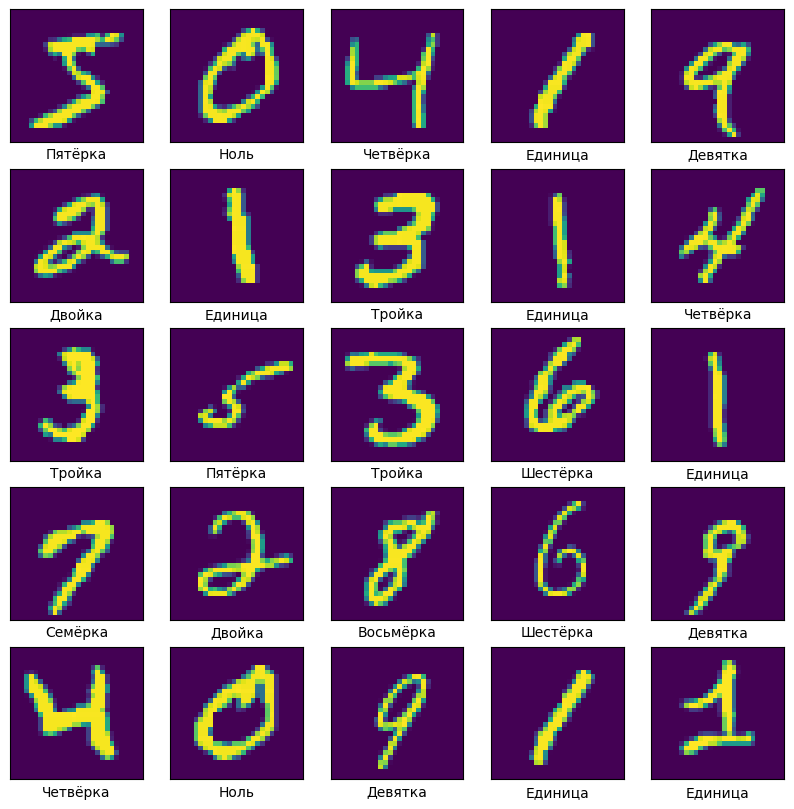

In [54]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train[i])
    plt.xlabel(class_names[y_train[i]])

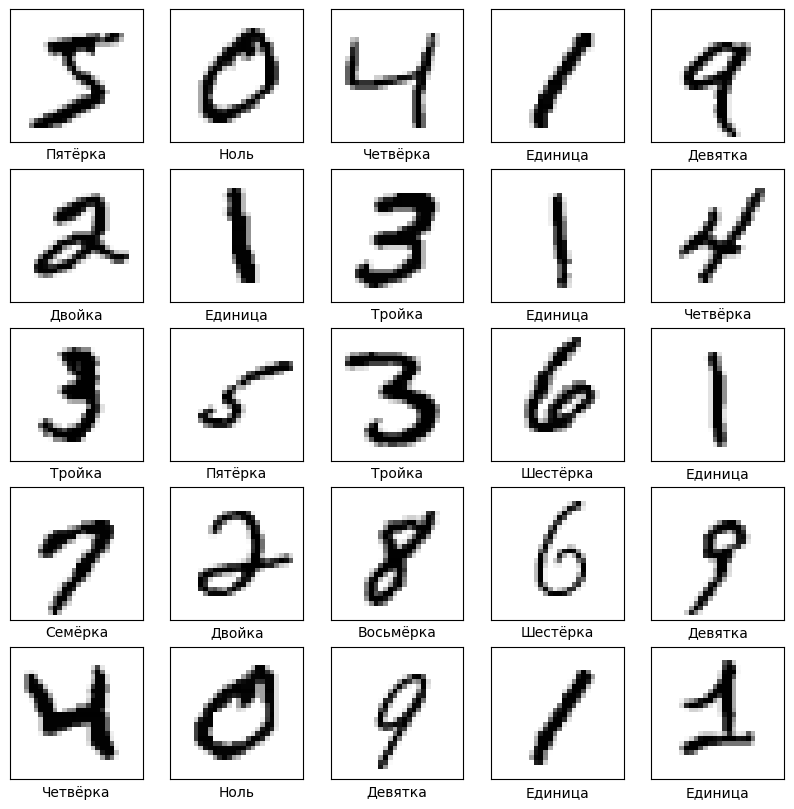

In [55]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])

___

### Построение модели нейронной сети 

In [ ]:
# входной слой с преображением изображения
model    = keras.Sequential([keras.layers.Flatten(input_shape=(28,28)),
                          # скрытый слой, изменяющий входные значения и 
                          # возвращающий единственное значение на следующий слой
                         keras.layers.Dense(128, activation='relu'),
                         keras.layers.Dense(10, activation='softmax')])

компилируем модель, задавая правила, по котоорым она будет учиться

In [63]:
model.compile(optimizer='adam', # алгоритм оптимизации, обновляющий
              # веса нейронной сети в процеесе обеучения
              
              # измеряем, насколько предсказания модели отличаются от правильных ответов
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [64]:
# тоже самое, только имеем другой тип оптимизатора
model.compile(optimizer=tf.keras.optimizers.SGD(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [65]:
# структурная сводка модели
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

### Тренируем модель

In [68]:
model.fit(x_train, y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9718 - loss: 0.1023
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9730 - loss: 0.0988
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9741 - loss: 0.0953
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9744 - loss: 0.0923
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9755 - loss: 0.0895
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9759 - loss: 0.0866
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9773 - loss: 0.0839
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1000us/step - accuracy: 0.9781 - loss: 0.0814
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9785 - loss: 0.0791  
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 999us/step - accuracy: 0.9796 - loss: 0.0769


In [69]:
model.fit(x_train, y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9798 - loss: 0.0746
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9803 - loss: 0.0728 
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9806 - loss: 0.0708
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9814 - loss: 0.0689
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9819 - loss: 0.0671
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9824 - loss: 0.0654  
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 991us/step - accuracy: 0.9830 - loss: 0.0638
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9833 - loss: 0.0623  
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9836 - loss: 0.0609
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9840 - loss: 0.0595


___

### Проверяем точность

In [70]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print('Тестовая точность:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 851us/step - accuracy: 0.9731 - loss: 0.0837
Тестовая точность: 0.9731000065803528


In [72]:
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 682us/step


In [73]:
predictions[15]

array([1.8881670e-05, 3.7217801e-04, 3.2726963e-05, 2.5477154e-02,
       4.9399415e-07, 9.7285908e-01, 3.5587891e-05, 1.6103414e-06,
       1.1058815e-03, 9.6401207e-05], dtype=float32)

In [74]:
np.argmax(predictions[15])

np.int64(5)

In [75]:
y_test[15]

np.uint8(5)

In [76]:
class_names[np.argmax(predictions[15])]

'Пятёрка'

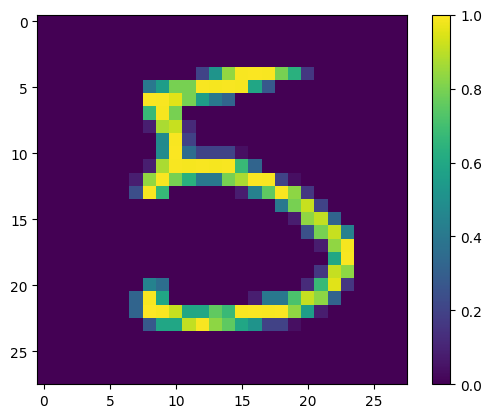

In [77]:
plt.figure()
plt.imshow(x_test[15])
plt.colorbar()
plt.grid(False)

___

### Предсказываем и исследуем

In [78]:
predictions = model.predict(x_train)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 612us/step


In [79]:
predictions[0]

array([1.8964172e-07, 3.2500932e-07, 2.0057330e-06, 3.1069553e-02,
       8.5296581e-13, 9.6892750e-01, 2.1011504e-10, 9.5968176e-08,
       9.7421058e-09, 3.7340624e-07], dtype=float32)

In [80]:
np.argmax(predictions[6])

np.int64(1)

In [81]:
y_train[6]

np.uint8(1)

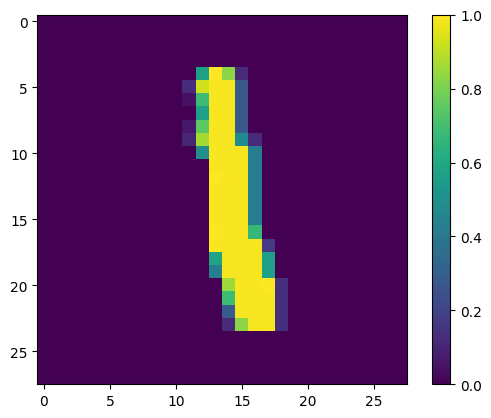

In [82]:
plt.figure()
plt.imshow(x_train[6])
plt.colorbar()
plt.grid(False)

In [83]:
class_names[np.argmax(predictions[6])]

'Единица'

In [85]:
model.save_weights('model11.weights.h5')